In [ ]:
# installing libraries:
# darts: time series forecasting framework (has AutoARIMA and LSTM)
# pytorch-lightning & torch: LSTM neural network
# statsforecast: stat models (darts AutoARIMA)

# had to do numpy<2 cuz version mismatch and kept giving me an error
!pip install -q darts pytorch-lightning torch statsforecast "numpy<2"

# restart the runtime
import os
os.kill(os.getpid(), 9)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

# darts for time series models
from darts import TimeSeries
from darts.models import AutoARIMA, RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape, mae, rmse

# statsmodels stationarity testing & ACF/PACF plots
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import time
import warnings
warnings.filterwarnings('ignore')
import logging
logging.disable(logging.CRITICAL)

## step 1: data collection & preprocessing

The dataset is Amazon daily stock data from MacroTrends, spanning from the 1997 through early 2026. Prices are split-adjusted so we can compare across the full data history.

In [ ]:
# load the csv — skiprows=1 because the raw MacroTrends has a title row above the actual column headers
amazon_df = pd.read_csv("amazon_data.csv", skiprows=1)

# quick check shape, column names, first few rows
print(f"Dataset shape: {amazon_df.shape[0]} rows x {amazon_df.shape[1]} columns")
print(f"Columns: {list(amazon_df.columns)}")
amazon_df.head()

Dataset shape: 7239 rows x 6 columns
Columns: ['date', 'open', 'high', 'low', 'close', 'volume']


,date,open,high,low,close,volume
0,1997-05-15,0.1219,0.1250,0.0964,0.0979,6009006
1,1997-05-16,0.0985,0.0990,0.0854,0.0865,1225710
2,1997-05-19,0.0880,0.0886,0.0813,0.0854,508901
3,1997-05-20,0.0865,0.0876,0.0818,0.0818,455879
4,1997-05-21,0.0818,0.0824,0.0688,0.0714,1572203


In [ ]:
# check for any missing values across the entire dataframe
# important to do this before anything
nan_present = amazon_df.isna().values.any()

In [ ]:
# convert the 'date' column from string to datetime then sort chronologically
amazon_df['date'] = pd.to_datetime(amazon_df['date'])
amazon_df = amazon_df.sort_values('date').reset_index(drop=True)

print(f"Date range: {amazon_df['date'].min().date()} to {amazon_df['date'].max().date()}")
print(f"Total trading days: {len(amazon_df)}")

Date range: 1997-05-15 to 2026-02-24
Total trading days: 7239


In [ ]:
# convert to a darts TimeSeries object for models
# using freq='B' (business days) so weekends are excluded from the time index
# fill_missing_dates=True adds rows for any holidays that are missing from the data
series = TimeSeries.from_dataframe(amazon_df, "date", "close", fill_missing_dates=True, freq="B")

# count how many nans values (these are holidays)
nan_count = np.isnan(series.values()).sum()
print(f"Length after filling dates: {len(series)}")
print(f"Holiday NaNs: {nan_count}")

# fill the holiday nans using linear interpolation between the trading days
# before and after this gives a reasonable estimate for the missing days and the values are 0
values = pd.Series(series.values().flatten(), index=series.time_index)
values = values.interpolate(method='linear').bfill().ffill()
series = TimeSeries.from_times_and_values(times=values.index, values=values.values, freq="B")

# verify no nan
print(f"NaNs?: {np.isnan(series.values()).sum()}")

Length after filling dates: 7509
Holiday NaNs: 270
NaNs?: 0


In [ ]:
# log10 transformations for the EDA visualizations
# stock price and volume data are heavily right-skewed log transform compress skew so we can actually see the distribution shape in histograms
amazon_df['log10_vol'] = np.log10(amazon_df['volume'])
amazon_df['log_close'] = np.log10(amazon_df['close'])

print(f"Raw volume range:  {amazon_df['volume'].min():,.0f} to {amazon_df['volume'].max():,.0f}")
print(f"Log10 volume range: {amazon_df['log10_vol'].min():.2f} to {amazon_df['log10_vol'].max():.2f}")

Raw volume range:  22,300 to 223,133,406
Log10 volume range: 4.35 to 8.35


## EDA

Before building any models, we need to to understand the data visually such as what does the price history look like, how is it distributed, and what does the trading volume tell us?

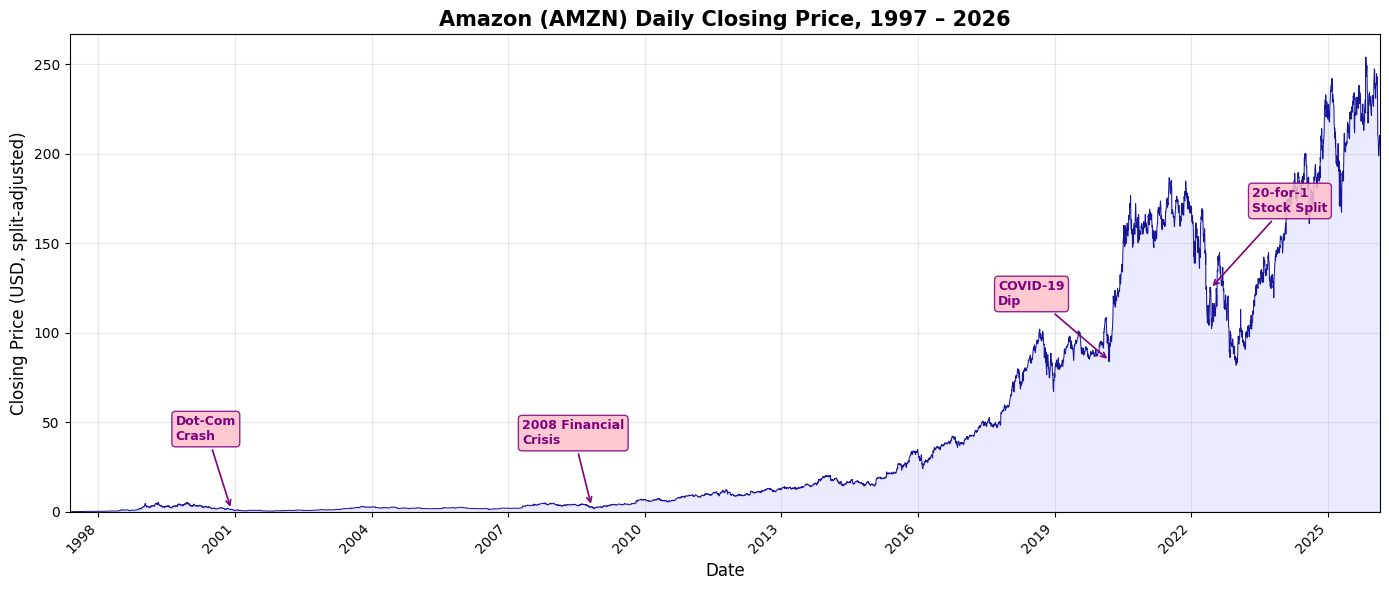

In [ ]:
# figure 1: Amazon daily closing price (1997-2026) with key events annotated
# shows the historical trend
fig1, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(amazon_df['date'], amazon_df['close'], linewidth=0.7, color='darkblue', alpha=0.9)
ax1.fill_between(amazon_df['date'], amazon_df['close'], alpha=0.08, color='blue')

ax1.set_title("Amazon (AMZN) Daily Closing Price, 1997 – 2026", fontsize=15, fontweight='bold')
ax1.set_xlabel("Date", fontsize=12)
ax1.set_ylabel("Closing Price (USD, split-adjusted)", fontsize=12)
ax1.xaxis.set_major_locator(mdates.YearLocator(3))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# key events
events = [
    ("2000-12-01", "Dot-Com\nCrash", (-40, 50)),
    ("2008-11-01", "2008 Financial\nCrisis", (-50, 45)),
    ("2020-03-16", "COVID-19\nDip", (-80, 40)),
    ("2022-06-06", "20-for-1\nStock Split", (30, 55)),
]

for date_str, label, offset in events:
    evt_date = pd.to_datetime(date_str)
    row = amazon_df.loc[(amazon_df['date'] - evt_date).abs().idxmin()]
    ax1.annotate(
        label,
        xy=(row['date'], row['close']),
        xytext=offset,
        textcoords='offset points',
        fontsize=9, fontweight='bold', color='purple',
        arrowprops=dict(arrowstyle='->', color='purple', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='pink', ec='purple', alpha=0.85),
    )

ax1.set_xlim(amazon_df['date'].min(), amazon_df['date'].max())
ax1.set_ylim(bottom=0)
fig1.tight_layout()
plt.show()

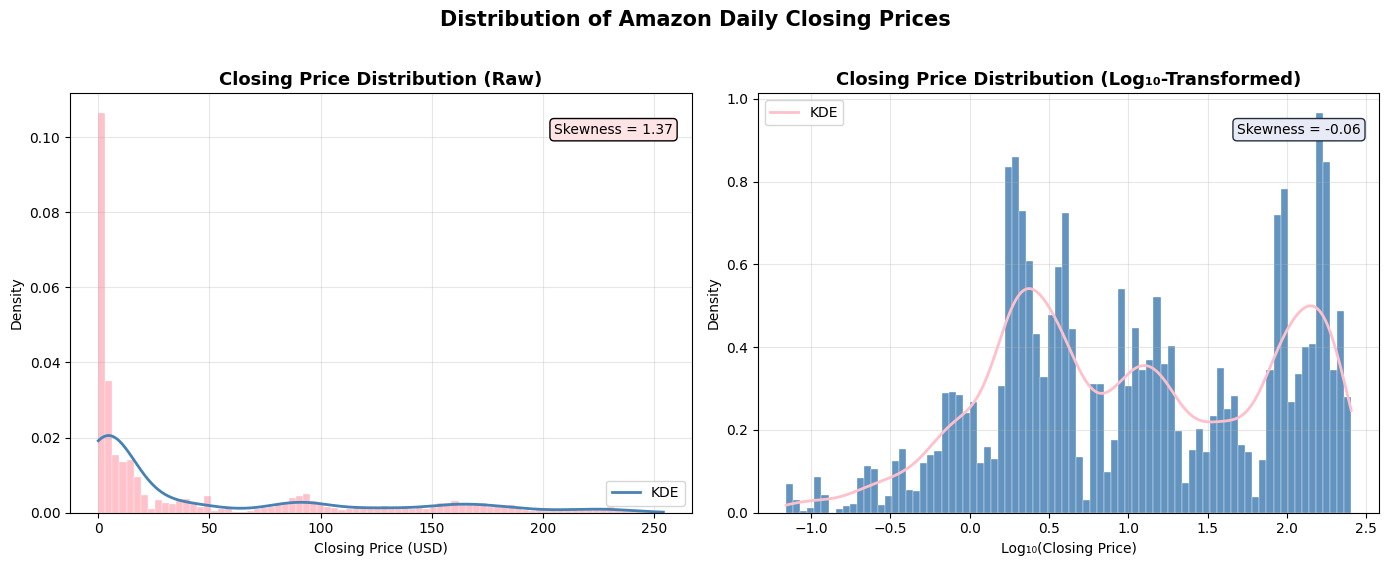

In [ ]:
# figure 2: distribution comparison — raw vs log-transformed closing prices
# show the right-skewed of the data and how log transform normalizes it
fig2, (ax2a, ax2b) = plt.subplots(1, 2, figsize=(14, 5.5))

# raw closing price histogram + KDE
ax2a.hist(amazon_df['close'], bins=80, color='lightpink', edgecolor='white',
          linewidth=0.3, alpha=0.85, density=True)
kde_x = np.linspace(amazon_df['close'].min(), amazon_df['close'].max(), 500)
kde = gaussian_kde(amazon_df['close'])
ax2a.plot(kde_x, kde(kde_x), color='steelblue', lw=2, label='KDE')
ax2a.legend()
ax2a.set_title("Closing Price Distribution (Raw)", fontsize=13, fontweight='bold')
ax2a.set_xlabel("Closing Price (USD)")
ax2a.set_ylabel("Density")
ax2a.grid(True, alpha=0.3)

skew_val = amazon_df['close'].skew()
ax2a.text(0.97, 0.93, f"Skewness = {skew_val:.2f}",
          transform=ax2a.transAxes, ha='right', va='top', fontsize=10,
          bbox=dict(boxstyle='round,pad=0.3', fc='#ffe4e6'))

# log10-transformed histogram + KDE
ax2b.hist(amazon_df['log_close'], bins=80, color='steelblue', edgecolor='white',
          linewidth=0.3, alpha=0.85, density=True)
kde_x_log = np.linspace(amazon_df['log_close'].min(), amazon_df['log_close'].max(), 500)
kde_log = gaussian_kde(amazon_df['log_close'])
ax2b.plot(kde_x_log, kde_log(kde_x_log), color='pink', lw=2, label='KDE')
ax2b.legend()
ax2b.set_title("Closing Price Distribution (Log\u2081\u2080-Transformed)", fontsize=13, fontweight='bold')
ax2b.set_xlabel("Log\u2081\u2080(Closing Price)")
ax2b.set_ylabel("Density")
ax2b.grid(True, alpha=0.3)

skew_log = amazon_df['log_close'].skew()
ax2b.text(0.97, 0.93, f"Skewness = {skew_log:.2f}",
          transform=ax2b.transAxes, ha='right', va='top', fontsize=10,
          bbox=dict(boxstyle='round,pad=0.3', fc='#E8EAF6', ec='#232F3E'))

fig2.suptitle("Distribution of Amazon Daily Closing Prices", fontsize=15, fontweight='bold', y=1.02)
fig2.tight_layout()
plt.show()

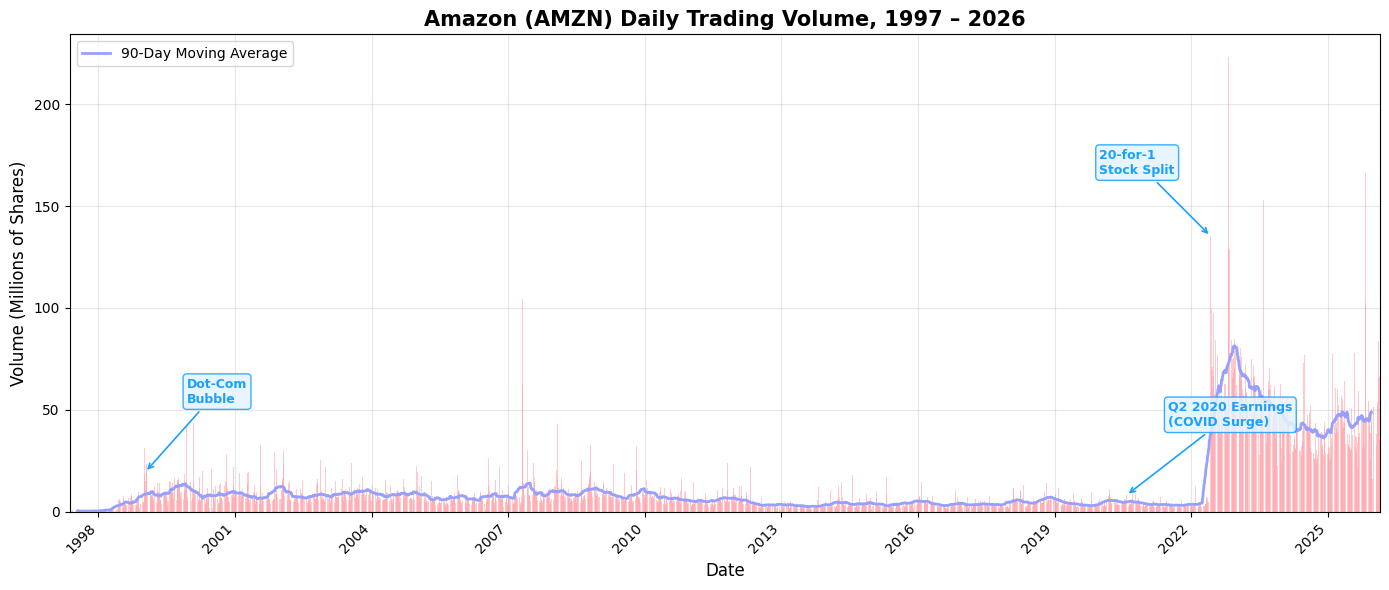

In [ ]:
# figure 3: trading volume over time with 90-day rolling average
fig3, ax3 = plt.subplots(figsize=(14, 6))

ax3.bar(amazon_df['date'], amazon_df['volume'] / 1e6, width=2,
        color='#ff979f', alpha=0.5, linewidth=0)

amazon_df['vol_ma90'] = amazon_df['volume'].rolling(window=90, center=True).mean()
ax3.plot(amazon_df['date'], amazon_df['vol_ma90'] / 1e6, color='#979fff', lw=2,
         label='90-Day Moving Average', zorder=3)

ax3.set_title("Amazon (AMZN) Daily Trading Volume, 1997 – 2026", fontsize=15, fontweight='bold')
ax3.set_xlabel("Date", fontsize=12)
ax3.set_ylabel("Volume (Millions of Shares)", fontsize=12)
ax3.xaxis.set_major_locator(mdates.YearLocator(3))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)

vol_events = [
    ("2020-07-31", "Q2 2020 Earnings\n(COVID Surge)", (30, 50)),
    ("2022-06-06", "20-for-1\nStock Split", (-80, 45)),
    ("1999-01-11", "Dot-Com\nBubble", (30, 50)),
]

for date_str, label, offset in vol_events:
    evt_date = pd.to_datetime(date_str)
    row = amazon_df.loc[(amazon_df['date'] - evt_date).abs().idxmin()]
    ax3.annotate(
        label,
        xy=(row['date'], row['volume'] / 1e6),
        xytext=offset,
        textcoords='offset points',
        fontsize=9, fontweight='bold', color='#19a1ff',
        arrowprops=dict(arrowstyle='->', color='#19a1ff', lw=1.2),
        bbox=dict(boxstyle='round,pad=0.3', fc='#e4f4ff', ec='#19a1ff', alpha=0.85),
    )

ax3.set_xlim(amazon_df['date'].min(), amazon_df['date'].max())
ax3.set_ylim(bottom=0)
fig3.tight_layout()
plt.show()

## stationarity resting & ACF/PACF analysis

Time series models like ARIMA require the data to be stationary which means that the stats like mean and variance dont need to change over time. Stock prices are almost never stationary because they trend up or down, so we need to check and then difference the data to make it stationary.

In [ ]:
# what ACF and PACF measure:
# ACF (Autocorrelation Function): measures the total correlation between the series at time t and time t-k including indirect correlations
# helps identify the MA order (q) for ARIMA
# PACF (Partial Autocorrelation Function): measures the direct correlation between time t and t-k removing the effect of all intermediate lags
# helps identify the AR order (p) for ARIMA

In [ ]:
# ADF (Augmented Dickey-Fuller) test standard test for stationarity
# null hypothesis: the series is non-stationary
# if p-value > 0.05 fail to reject series is non-stationary need differencing

result_raw = adfuller(amazon_df['close'].dropna())
print("ADF Test on Raw Close Prices:")
print(f"  ADF Statistic: {result_raw[0]:.4f}")
print(f"  p-value:       {result_raw[1]:.6f}")
print(f"  Lags Used:     {result_raw[2]}")
print(f"  Stationary?    {'Yes' if result_raw[1] < 0.05 else 'No'}")

# now test on first-differenced prices (d=1): price_today - price_yesterday
# differencing removes the trend which should make the series stationary
diff_close = amazon_df['close'].diff().dropna()
result_diff = adfuller(diff_close)
print("\nADF Test on Differenced Close Prices (d=1):")
print(f"  ADF Statistic: {result_diff[0]:.4f}")
print(f"  p-value:       {result_diff[1]:.6f}")
print(f"  Stationary?    {'Yes' if result_diff[1] < 0.05 else 'No'}")

ADF Test on Raw Close Prices:
  ADF Statistic: 0.6371
  p-value:       0.988495
  Lags Used:     36
  Stationary?    No

ADF Test on Differenced Close Prices (d=1):
  ADF Statistic: -14.5635
  p-value:       0.000000
  Stationary?    Yes


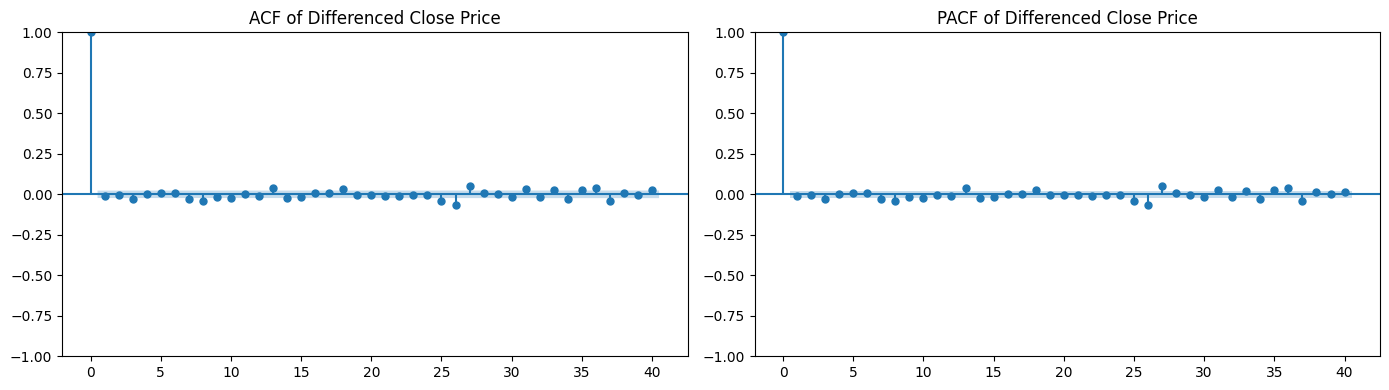

In [ ]:
# ACF and PACF on the differenced series
# ACF = how many lags show significant correlation = suggests MA order (q)
# PACF = how many lags show significant partial correlation = suggests AR order (p)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff_close, lags=40, ax=axes[0], title="ACF of Differenced Close Price")
plot_pacf(diff_close, lags=40, ax=axes[1], title="PACF of Differenced Close Price")
plt.tight_layout()
plt.show()

## train / validation / test split

Using an 80/10/10 split the model trains on the first 80% of the data (1997–2019) then validates hyperparameters on the next 10% (2019–2022) and the final 10% (2022–2026) is a test set to get an performance estimate.

Train: 6007 days  (1997-05-15 → 2020-05-22)
Val:   751 days  (2020-05-25 → 2023-04-10)
Test:  751 days  (2023-04-11 → 2026-02-24)
  Train NaNs: 0
  Val NaNs: 0
  Test NaNs: 0


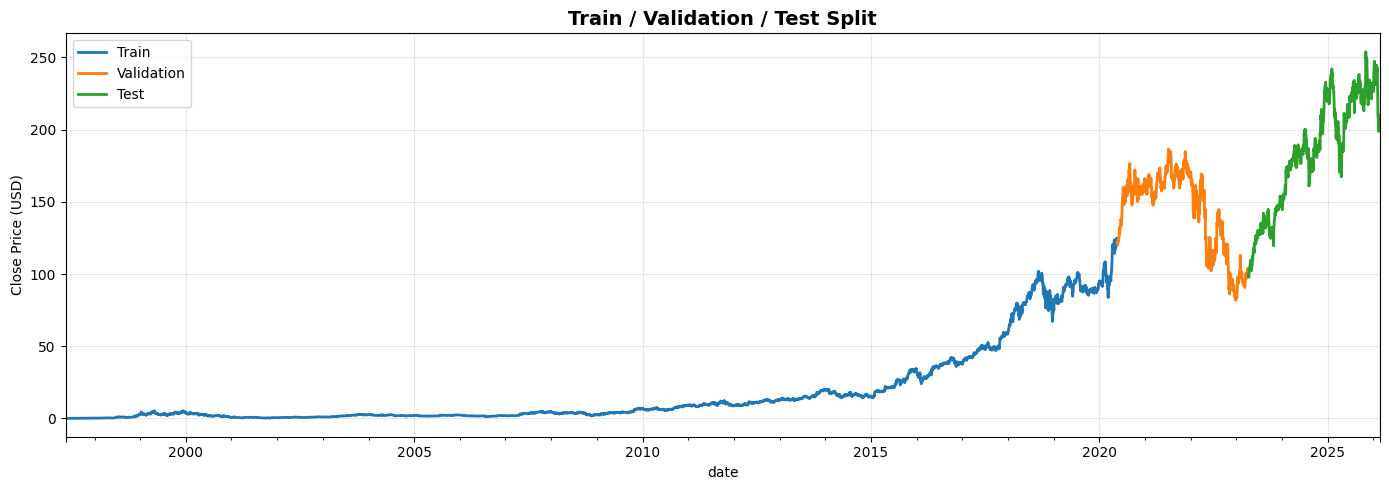

In [ ]:
# 80/10/10 chronological split no shuffle cuz time series
# future data must never leak into training - learned the hard way :(
n = len(series)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

train = series[:train_end]
val   = series[train_end:val_end]
test  = series[val_end:]

print(f"Train: {len(train)} days  ({series.time_index[0].date()} → {series.time_index[train_end-1].date()})")
print(f"Val:   {len(val)} days  ({series.time_index[train_end].date()} → {series.time_index[val_end-1].date()})")
print(f"Test:  {len(test)} days  ({series.time_index[val_end].date()} → {series.time_index[-1].date()})")

# verify no nan
for name, s in [("Train", train), ("Val", val), ("Test", test)]:
    nans = np.isnan(s.values()).sum()
    print(f"  {name} NaNs: {nans}")

# plot the split
fig, ax = plt.subplots(figsize=(14, 5))
train.plot(label="Train", ax=ax)
val.plot(label="Validation", ax=ax)
test.plot(label="Test", ax=ax)
ax.set_title("Train / Validation / Test Split", fontsize=14, fontweight='bold')
ax.set_ylabel("Close Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ARIMA model

ARIMA (AutoRegressive Integrated Moving Average) is a statistical model for time series forecasting. It combines three components AR (p): uses past values to predict the current value I (d): differencing to make the series stationary (we confirm d 1 works) MA (q): uses past forecast errors to refine predictions. I'm used AutoARIMA (seen on other timeseries forecasting and reddit) which auto searches through different (p, d, q) combinations and picks the best one based on the AIC (Akaike Information Criterion).
lower AIC = better model fit without overfitting

In [ ]:
# AutoARIMA automatically searches for the best (p, d, q) combination
# d=1 is fixed based on our ADF test results
# seasonal= false cuz daily stock data doesn't have clear seasonal patterns unlike something like monthly retail sales which peaks every December

start = time.time()

auto_arima = AutoARIMA(
    d=1,               # first-order differencing (from ADF test)
    seasonal=False,    # no seasonality in daily stock prices
)
auto_arima.fit(train)

elapsed = time.time() - start
print(f"AA completed in {elapsed:.1f}s")

AA completed in 24.6s


In [ ]:
# generate ARIMA predictions for the validation period then calculate error metrics to see how well it does
pred_val_arima = auto_arima.predict(len(val))

val_mae_arima  = mae(val, pred_val_arima)
val_rmse_arima = rmse(val, pred_val_arima)
val_mape_arima = mape(val, pred_val_arima)

print("ARIMA Validation Metrics:")
print(f"  MAE:  ${val_mae_arima:.2f}")
print(f"  RMSE: ${val_rmse_arima:.2f}")
print(f"  MAPE: {val_mape_arima:.2f}%")

ARIMA Validation Metrics:
  MAE:  $31.71
  RMSE: $34.22
  MAPE: 22.96%


In [ ]:
# for the final test evaluation retrain ARIMA on train+val combined give model the most data possible before using on unseen test set
train_val = series[:val_end]

auto_arima_final = AutoARIMA(
    d=1,
    seasonal=False,
)
auto_arima_final.fit(train_val)

pred_test_arima = auto_arima_final.predict(len(test))

# MAE  = average absolute dollar error
# RMSE = root mean squared error
# MAPE = mean absolute percentage error
test_mae_arima  = mae(test, pred_test_arima)
test_rmse_arima = rmse(test, pred_test_arima)
test_mape_arima = mape(test, pred_test_arima)

print("ARIMA Test Set Metrics:")
print(f"  MAE:  ${test_mae_arima:.2f}")
print(f"  RMSE: ${test_rmse_arima:.2f}")
print(f"  MAPE: {test_mape_arima:.2f}%")

ARIMA Test Set Metrics:
  MAE:  $77.52
  RMSE: $85.24
  MAPE: 39.39%


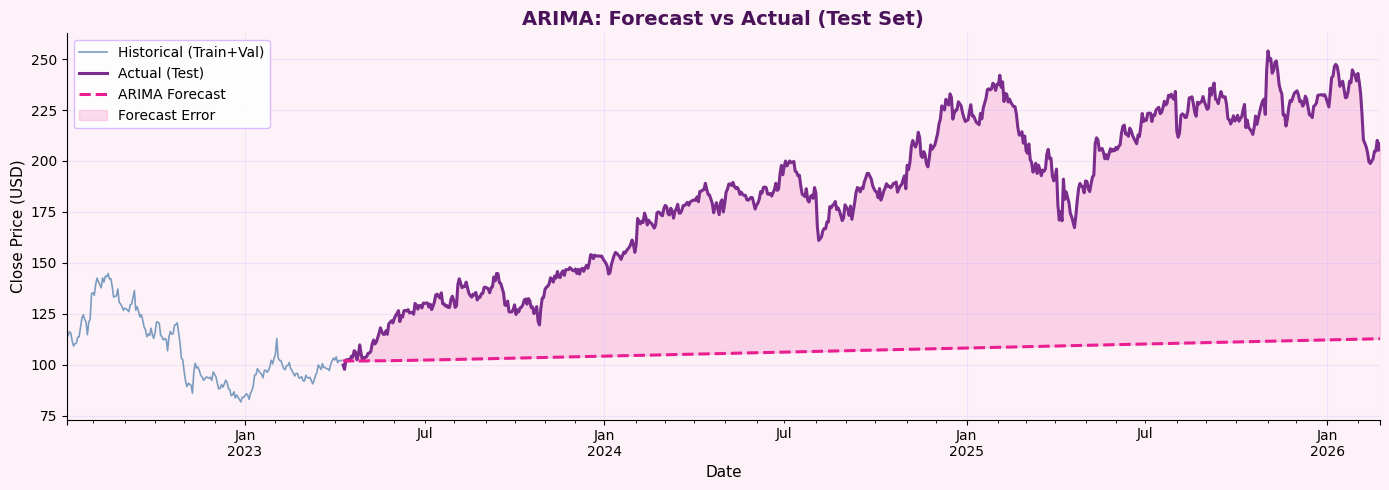

In [ ]:
# ARIMA forecast vs actual on the test set
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#fdf2f8')
ax.set_facecolor('#fdf2f8')

context_start = max(0, val_end - 200)

# historical data
series[context_start:val_end].plot(label="Historical (Train+Val)", ax=ax, lw=1.2, color='#7c9cbf')

# actual test prices
test.plot(label="Actual (Test)", ax=ax, lw=2.2, color='#7b2d8e')

# ARIMA forecast
pred_test_arima.plot(label="ARIMA Forecast", ax=ax, lw=2.2, linestyle='--', color='#e91e90')

# gap between actual and forecast
test_idx = test.time_index
ax.fill_between(test_idx,
                test.values().flatten(),
                pred_test_arima.values().flatten(),
                alpha=0.15, color='#e91e90', label='Forecast Error')

ax.set_title("ARIMA: Forecast vs Actual (Test Set)", fontsize=14, fontweight='bold', color='#4a1259')
ax.set_ylabel("Close Price (USD)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(fontsize=10, facecolor='white', edgecolor='#d8b4fe', framealpha=0.9)
ax.grid(True, alpha=0.25, color='#c4b5fd')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## LSTM model

LSTM (Long Short-Term Memory) is a type of recurrent neural network specifically designed to learn long range in sequential data. Unlike ARIMA which is a linear model LSTM can capture non linear patterns in the data.

In [ ]:
# LSTM requires normalization neural networks train much better when inputs are scaled in small range
# scaler only on training data so no data leakage
# if we fit on the full dataset the model would implicitly know future price ranges

scaler = Scaler()
train_scaled = scaler.fit_transform(train)      # fit on train transform train
val_scaled   = scaler.transform(val)             # transform val using trains fit
test_scaled  = scaler.transform(test)            # transform test using trains fit
series_scaled = scaler.transform(series)         # full series scaled

# check the scaled ranges
print(f"Train scaled range: [{train_scaled.values().min():.4f}, {train_scaled.values().max():.4f}]")
print(f"Val scaled range:   [{val_scaled.values().min():.4f}, {val_scaled.values().max():.4f}]")
print(f"Test scaled range:  [{test_scaled.values().min():.4f}, {test_scaled.values().max():.4f}]")

Train scaled range: [0.0000, 1.0000]
Val scaled range:   [0.6549, 1.4941]
Test scaled range:  [0.7832, 2.0343]


In [ ]:
# building the LSTM model using darts RNNModel wrapper
# hyperparameter:
# input_chunk_length=60 = window of 60 trading days (3 months) gives the model history to detect trends
# training_length=120 = total sequence length per training sample must be more than input_chunk_length
# hidden_dim=64 = 64 hidden units per LSTM layer enough capacity without overfit
# n_rnn_layers=2 = 2 stacked LSTM layers for deeper feature extraction dropout=0.2 = randomly zeros 20% of neurons during training to prevent overfit
# n_epochs=100 = max training passes
# lr=1e-3 = learning rate standard starting point
# the model is recurrent so at prediction time it feeds each predicted value back as input for the next step (autoregressive generation)
# a lot of this i had to search up to see what the norm was for other people and their datasets
import pytorch_lightning as pl

model_lstm = RNNModel(
    model="LSTM",
    input_chunk_length=60,
    training_length=120,
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "callbacks": [
            pl.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                mode="min",
            )
        ],
    },
)

print(model_lstm)

RNNModel(model=LSTM, hidden_dim=64, n_rnn_layers=2, dropout=0.2, training_length=120, input_chunk_length=60, batch_size=32, n_epochs=100, optimizer_kwargs={'lr': 0.001}, random_state=42, force_reset=True, pl_trainer_kwargs={'enable_progress_bar': True, 'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x78b775e105c0>]})


In [ ]:
# train the LSTM on scaled training data validating on scaled validation data
# early stopping monitors val_loss training will stop automatically
# if the model hasnt improved for 10 consecutive epochs
start = time.time()

model_lstm.fit(
    series=train_scaled,
    val_series=val_scaled,
    verbose=True,
)

elapsed = time.time() - start
print(f"\ntraining completed in {elapsed:.1f}s")

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


training completed in 223.5s


In [ ]:
# generate LSTM predictions on the validation period
# predict on scaled data then inverse_transform back to real dollar values
pred_val_lstm_scaled = model_lstm.predict(n=len(val), series=train_scaled)
pred_val_lstm = scaler.inverse_transform(pred_val_lstm_scaled)

val_mae_lstm  = mae(val, pred_val_lstm)
val_rmse_lstm = rmse(val, pred_val_lstm)
val_mape_lstm = mape(val, pred_val_lstm)

print("LSTM Validation Metrics:")
print(f"  MAE:  ${val_mae_lstm:.2f}")
print(f"  RMSE: ${val_rmse_lstm:.2f}")
print(f"  MAPE: {val_mape_lstm:.2f}%")

Predicting: |          | 0/? [00:00<?, ?it/s]

LSTM Validation Metrics:
  MAE:  $57.62
  RMSE: $64.20
  MAPE: 37.34%


In [ ]:
# retrain LSTM on train+val combined for the test eval w more data
train_val_scaled = scaler.transform(train_val)

model_lstm_final = RNNModel(
    model="LSTM",
    input_chunk_length=60,
    training_length=120,
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "callbacks": [
            pl.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                mode="min",
            )
        ],
    },
)

model_lstm_final.fit(
    series=train_val_scaled,
    val_series=test_scaled,
    verbose=True,
)

# predict on the test period and convert back to dollar values
pred_test_lstm_scaled = model_lstm_final.predict(n=len(test), series=train_val_scaled)
pred_test_lstm = scaler.inverse_transform(pred_test_lstm_scaled)

test_mae_lstm  = mae(test, pred_test_lstm)
test_rmse_lstm = rmse(test, pred_test_lstm)
test_mape_lstm = mape(test, pred_test_lstm)

print("\nLSTM Test Set Metrics:")
print(f"  MAE:  ${test_mae_lstm:.2f}")
print(f"  RMSE: ${test_rmse_lstm:.2f}")
print(f"  MAPE: {test_mape_lstm:.2f}%")

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]


LSTM Test Set Metrics:
  MAE:  $30.36
  RMSE: $36.21
  MAPE: 16.10%


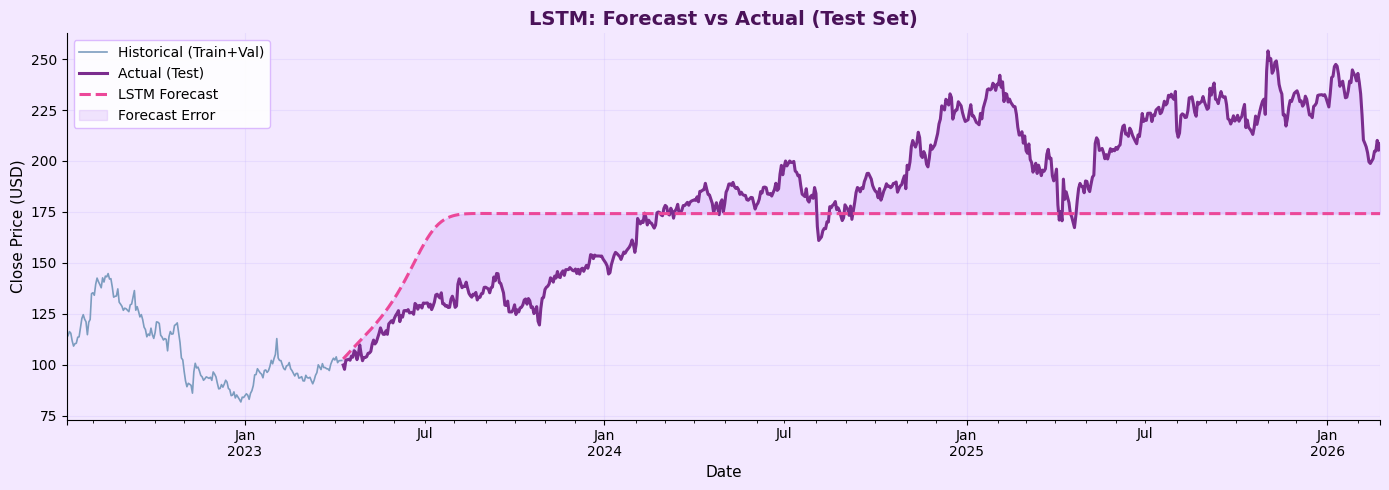

In [ ]:
# LSTM forecast vs actual on the test set
fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#f3e8ff')
ax.set_facecolor('#f3e8ff')

# historical context
series[max(0, val_end - 200):val_end].plot(label='Historical (Train+Val)', ax=ax, lw=1.2, color='#7c9cbf')

# actual test prices
test.plot(label='Actual (Test)', ax=ax, lw=2.2, color='#7b2d8e')

# LSTM forecast
pred_test_lstm.plot(label='LSTM Forecast', ax=ax, lw=2.2, linestyle='--', color='#ec4899')

# error area
test_idx = test.time_index
ax.fill_between(test_idx,
                test.values().flatten(),
                pred_test_lstm.values().flatten(),
                alpha=0.15, color='#a855f7', label='Forecast Error')

ax.set_title("LSTM: Forecast vs Actual (Test Set)", fontsize=14, fontweight='bold', color='#4a1259')
ax.set_ylabel("Close Price (USD)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(fontsize=10, facecolor='white', edgecolor='#d8b4fe', framealpha=0.9)
ax.grid(True, alpha=0.25, color='#c4b5fd')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## model comparison: ARIMA vs LSTM


In [ ]:
# side-by-side comparison of both models on the test set
comparison = pd.DataFrame({
    'Metric': ['MAE ($)', 'RMSE ($)', 'MAPE (%)'],
    'ARIMA':  [f'{test_mae_arima:.2f}', f'{test_rmse_arima:.2f}', f'{test_mape_arima:.2f}'],
    'LSTM':   [f'{test_mae_lstm:.2f}', f'{test_rmse_lstm:.2f}', f'{test_mape_lstm:.2f}']
})

print(comparison.to_string(index=False))

# MAPE is the most interpretable metric for comparison cuz scale independent
winner = "LSTM" if test_mape_lstm < test_mape_arima else "ARIMA"
print(f"\nbest model by MAPE: {winner}")

  Metric ARIMA  LSTM
 MAE ($) 77.52 30.36
RMSE ($) 85.24 36.21
MAPE (%) 39.39 16.10

best model by MAPE: LSTM


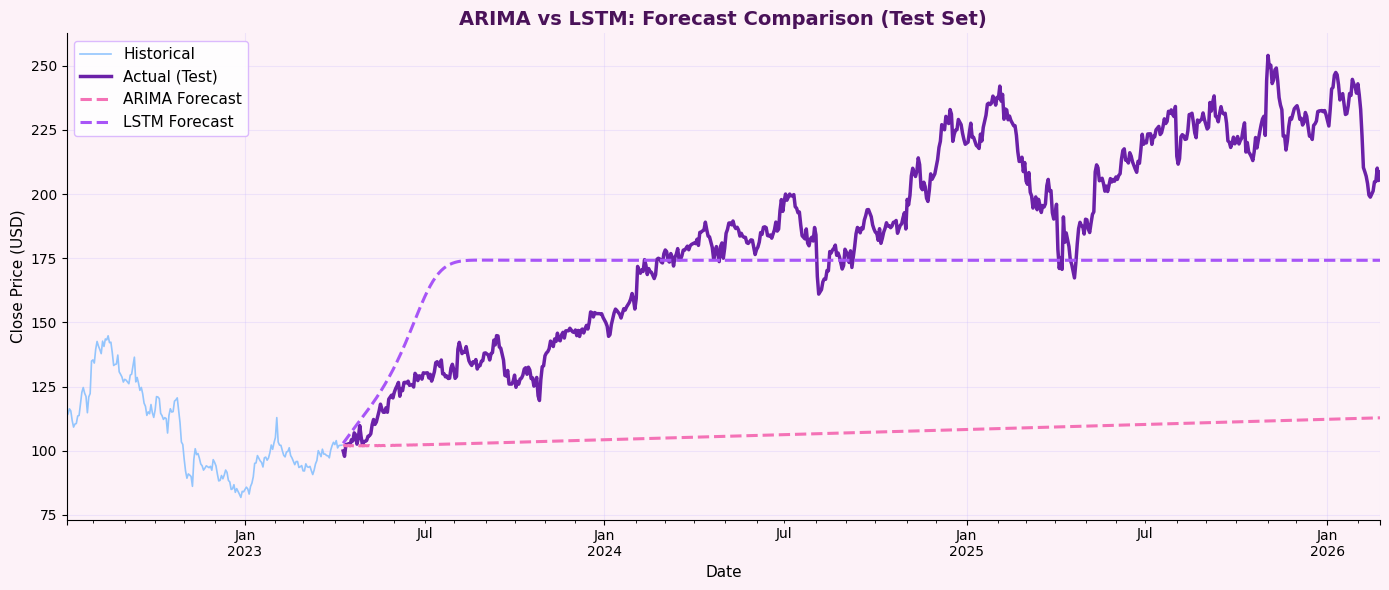

In [ ]:
# both models side-by-side on the test set
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#fdf2f8')
ax.set_facecolor('#fdf2f8')

# historical context
series[max(0, val_end - 200):val_end].plot(label='Historical', ax=ax, lw=1.2, color='#93c5fd')

# actual test
test.plot(label='Actual (Test)', ax=ax, lw=2.5, color='#6b21a8')

# ARIMA forecast
pred_test_arima.plot(label='ARIMA Forecast', ax=ax, lw=2.2, linestyle='--', color='#f472b6')

# LSTM forecast
pred_test_lstm.plot(label='LSTM Forecast', ax=ax, lw=2.2, linestyle='--', color='#a855f7')

ax.set_title("ARIMA vs LSTM: Forecast Comparison (Test Set)", fontsize=14, fontweight='bold', color='#4a1259')
ax.set_ylabel("Close Price (USD)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(fontsize=11, facecolor='white', edgecolor='#d8b4fe', framealpha=0.9)
ax.grid(True, alpha=0.25, color='#c4b5fd')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 2026 Forecast
using all the data

In [ ]:
# train ARIMA on the full dataset and forecast through end of 2026
auto_arima_full = AutoARIMA(d=1, seasonal=False)
auto_arima_full.fit(series)

# figure out how many business days we need to forecast
last_date = series.time_index[-1]
future_dates = pd.bdate_range(start=last_date + pd.offsets.BDay(1), end='2026-12-31')
n_forecast = len(future_dates)

print(f"Forecasting {n_forecast} business days from {future_dates[0].date()} to {future_dates[-1].date()}")
forecast_arima_2026 = auto_arima_full.predict(n_forecast)

Forecasting 222 business days from 2026-02-25 to 2026-12-31


In [ ]:
# train LSTM on the full scaled dataset and forecast through end of 2026
model_lstm_full = RNNModel(
    model="LSTM",
    input_chunk_length=60,
    training_length=120,
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.2,
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={"lr": 1e-3},
    random_state=42,
    force_reset=True,
    pl_trainer_kwargs={
        "enable_progress_bar": True,
        "callbacks": [
            pl.callbacks.EarlyStopping(
                monitor="train_loss",
                patience=10,
                mode="min",
            )
        ],
    },
)

model_lstm_full.fit(series=series_scaled, verbose=True)

# predict and inverse-transform back to dollar values
forecast_lstm_2026_scaled = model_lstm_full.predict(n=n_forecast, series=series_scaled)
forecast_lstm_2026 = scaler.inverse_transform(forecast_lstm_2026_scaled)

forecast_lstm_vals = forecast_lstm_2026.values().flatten()
print(f"LSTM 2026 forecast range: ${forecast_lstm_vals[0]:.2f} → ${forecast_lstm_vals[-1]:.2f}")

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

LSTM 2026 forecast range: $209.12 → $217.81


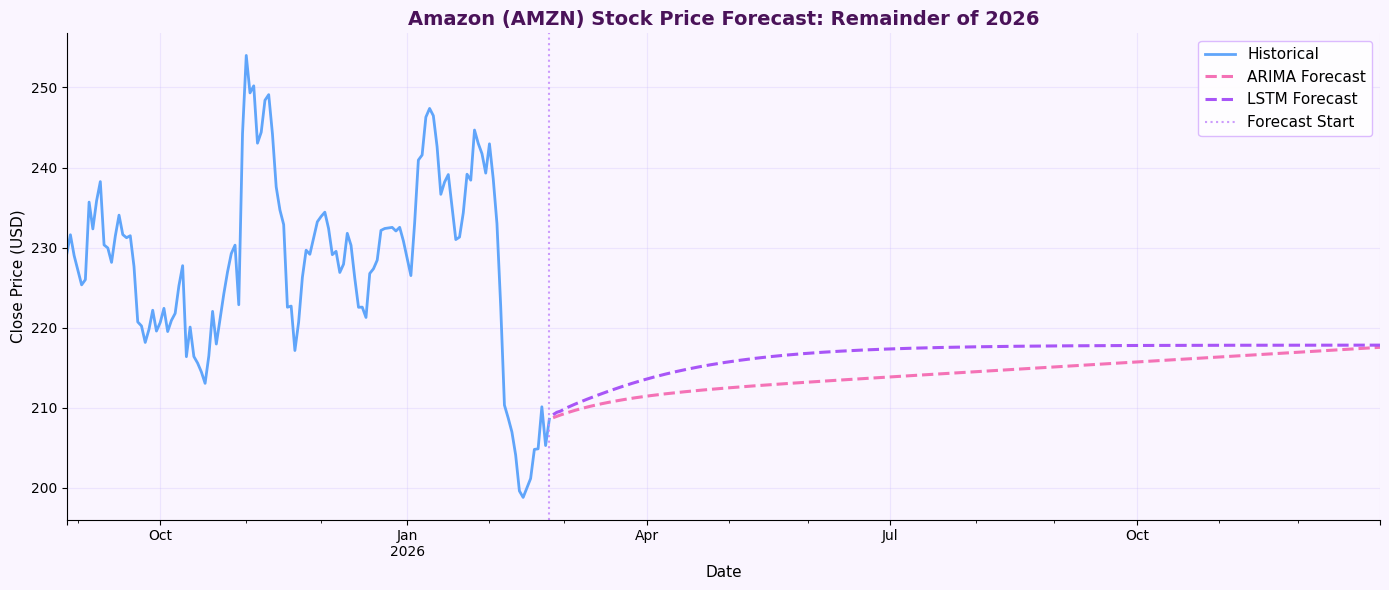


ARIMA end of 2026 prediction: $217.54
LSTM end of 2026 prediction:  $217.81


In [ ]:
# 2026 forecast both models with recent history for context
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#faf5ff')
ax.set_facecolor('#faf5ff')

# last 6 months of actual data
series[-130:].plot(label='Historical', ax=ax, lw=2, color='#60a5fa')

# ARIMA forecast
forecast_arima_2026.plot(label='ARIMA Forecast', ax=ax, lw=2.2, linestyle='--', color='#f472b6')

# LSTM forecast
forecast_lstm_2026.plot(label='LSTM Forecast', ax=ax, lw=2.2, linestyle='--', color='#a855f7')

ax.axvline(x=series.time_index[-1], color='#c084fc', linestyle=':', alpha=0.8, lw=1.5, label='Forecast Start')

ax.set_title("Amazon (AMZN) Stock Price Forecast: Remainder of 2026",
             fontsize=14, fontweight='bold', color='#4a1259')
ax.set_ylabel("Close Price (USD)", fontsize=11)
ax.set_xlabel("Date", fontsize=11)
ax.legend(fontsize=11, facecolor='white', edgecolor='#d8b4fe', framealpha=0.9)
ax.grid(True, alpha=0.25, color='#c4b5fd')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# end of year predictions
arima_2026_vals = forecast_arima_2026.values().flatten()
lstm_2026_vals  = forecast_lstm_2026.values().flatten()
print(f"\nARIMA end of 2026 prediction: ${arima_2026_vals[-1]:.2f}")
print(f"LSTM end of 2026 prediction:  ${lstm_2026_vals[-1]:.2f}")